<a href="https://colab.research.google.com/github/odamasceno/Calculo-Numerico/blob/main/AtividadeII_Overflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### Rafael Damasceno Marques dos Santos - RA: 187561

In [2]:
#importações
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

## Código Proposto

Maior float32: 3.4028235e+38
Maior float64: 1.7976931348623157e+308
dt=0.001, float32: 2000 passos sem overflow.
dt=0.002, float32: falha no passo 121, t=0.2420 s - overflow encountered in subtract
dt=0.001, float64: 2000 passos sem overflow.
dt=0.002, float64: falha no passo 917, t=1.8340 s - overflow encountered in add


/usr/local/lib/python3.13/dist-packages/matplotlib/scale.py:253: RuntimeWarning: overflow encountered in power
  return np.power(self.base, values)


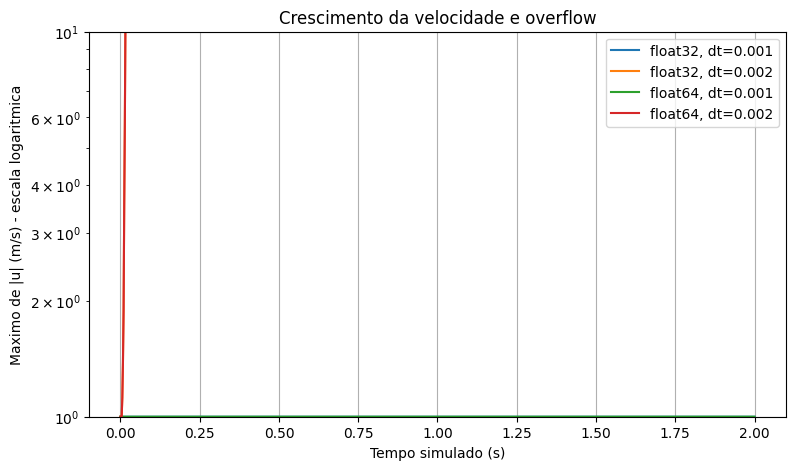

In [1]:


def simular(dt, tipo=np.float32, passos=2000, pontos=21):
    """Simula difusao de velocidade e detecta falhas."""

    H = 0.01
    nu = 1e-4

    y = np.linspace(0, H, pontos)
    dy = H / (pontos - 1)

    # Coeficientes no tipo numerico escolhido.
    r = tipo(nu * dt / dy**2)
    dois = tipo(2)

    # Fluido parado e placa em y=0 em movimento.
    u = np.zeros(pontos, dtype=tipo)
    u[0] = tipo(1)

    tempos = [0.0]
    maximos = [float(np.max(np.abs(u)))]
    falha = None

    # Transforma avisos numericos em excecoes.
    with np.errstate(over="raise", invalid="raise"):
        for passo in range(1, passos + 1):
            try:
                novo = u.copy()

                # Atualiza o interior e preserva as paredes.
                novo[1:-1] = (
                    u[1:-1]
                    + r * (
                        u[2:] - dois * u[1:-1] + u[:-2]
                    )
                )

            except FloatingPointError as erro:
                falha = passo
                print(
                    f"dt={dt}, {tipo.__name__}: "
                    f"falha no passo {passo}, "
                    f"t={passo * dt:.4f} s - {erro}"
                )
                break

            u = novo
            tempos.append(passo * dt)
            maximos.append(float(np.max(np.abs(u))))

    if falha is None:
        print(
            f"dt={dt}, {tipo.__name__}: "
            f"{passos} passos sem overflow."
        )

    return {
        "y": y,
        "u": u,
        "tempos": tempos,
        "maximos": maximos,
        "r": float(r),
        "falha": falha,
    }


print("Maior float32:", np.finfo(np.float32).max)
print("Maior float64:", np.finfo(np.float64).max)

resultados = {}

for tipo in (np.float32, np.float64):
    for dt in (0.001, 0.002):
        nome = f"{tipo.__name__}, dt={dt}"
        resultados[nome] = simular(dt, tipo)

plt.figure(figsize=(9, 5))

for nome, resultado in resultados.items():
    plt.semilogy(
        resultado["tempos"],
        resultado["maximos"],
        label=nome
    )

plt.xlabel("Tempo simulado (s)")
plt.ylabel("Maximo de |u| (m/s) - escala logaritmica")
plt.title("Crescimento da velocidade e overflow")
plt.grid(True)
plt.legend()
plt.show()

### Parte 1 e 2

In [4]:
#PARTE 1: Verificação da estabilidade
H = 0.01
nu = 1e-4
pontos = 21

dy = H / (pontos - 1)
dt_max = (dy**2) / (2 * nu)

print("1. VERIFICAÇÃO DE ESTABILIDADE")
print(f"Espaçamento (dy): {dy} m")
print(f"Limite de tempo (dt_max): {dt_max} s")

for dt, caso in zip([0.001, 0.002], ['A', 'B']):
    r = (nu * dt) / (dy**2)
    status = "Estável" if r <= 0.5 else "Instável"
    print(f"Caso {caso} (dt = {dt}): r = {r:.2f} -> {status}")

print("\n2. DETECÇÃO DE OVERFLOW")
dados_tabela = []
for tipo in [np.float32, np.float64]:
    for dt in [0.001, 0.002]:
        res = simular(dt, tipo)
        overflow = "Sim" if res["falha"] is not None else "Não"
        iteracao = res["falha"] if res["falha"] is not None else "N/A"
        dados_tabela.append({
            "Tipo": tipo.__name__,
            "dt (s)": dt,
            "Valor r": res["r"],
            "Overflow": overflow,
            "Iteração da Falha": iteracao
        })

tabela = pd.DataFrame(dados_tabela)
display(tabela)

1. VERIFICAÇÃO DE ESTABILIDADE
Espaçamento (dy): 0.0005 m
Limite de tempo (dt_max): 0.0012499999999999998 s
Caso A (dt = 0.001): r = 0.40 -> Estável
Caso B (dt = 0.002): r = 0.80 -> Instável

2. DETECÇÃO DE OVERFLOW
dt=0.001, float32: 2000 passos sem overflow.
dt=0.002, float32: falha no passo 121, t=0.2420 s - overflow encountered in subtract
dt=0.001, float64: 2000 passos sem overflow.
dt=0.002, float64: falha no passo 917, t=1.8340 s - overflow encountered in add


,Tipo,dt (s),Valor r,Overflow,Iteração da Falha
0,float32,0.001,0.4,Não,N/A
1,float32,0.002,0.8,Sim,121
2,float64,0.001,0.4,Não,N/A
3,float64,0.002,0.8,Sim,917


### Parte 3 e 4

dt=0.001, float32: 2000 passos sem overflow.
dt=0.002, float32: falha no passo 121, t=0.2420 s - overflow encountered in subtract
dt=0.001, float64: 2000 passos sem overflow.
dt=0.002, float64: falha no passo 917, t=1.8340 s - overflow encountered in add


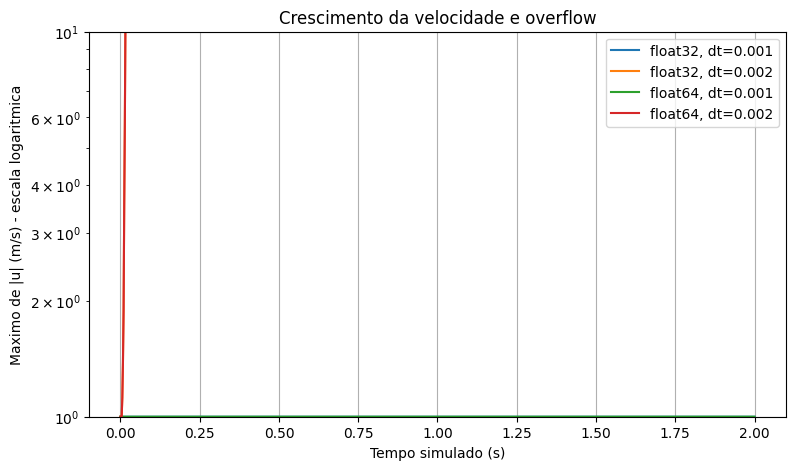

In [6]:
resultados = {}

for tipo in (np.float32, np.float64):
    for dt in (0.001, 0.002):
        nome = f"{tipo.__name__}, dt={dt}"
        resultados[nome] = simular(dt, tipo)

plt.figure(figsize=(9, 5))

for nome, resultado in resultados.items():
    plt.semilogy(
        resultado["tempos"],
        resultado["maximos"],
        label=nome
    )

plt.xlabel("Tempo simulado (s)")
plt.ylabel("Maximo de |u| (m/s) - escala logaritmica")
plt.title("Crescimento da velocidade e overflow")
plt.grid(True)
plt.legend()
plt.show()

### Resposta parte 3
O crescimento observado no caso instável, onde dt=0.002, não representa o comportamento físico porque a velocidade das partículas do fluido não pode ultrapassar a velocidade da própria placa que o está movendo (U = 1 m/s). Valores exponenciais configuram erro numérico do método de Euler, e não a física real do escoamento.

### Resposta parte 4
Mudar de float32 para float64 não elimina a instabilidade. O fator 'r' (0.8) continua sendo maior que 0.5, então o erro continua sendo amplificado. portando, a diferença é que o float64 consegue armazenar números muito maiores, e com isso leva mais iterações/passos para o erro estourar o limite da memória (overflow) do que o float32 (que aguenta só até ~3.4e38).

### Parte 5

In [7]:
#PARTE 5: Refinamento da malha
pontos_novo = 41
dt_antigo = 0.001
dy_novo = H / (pontos_novo - 1)
dt_max_novo = (dy_novo**2) / (2 * nu)

print("5. REFINAMENTO DA MALHA")
print(f"Espaçamento com 41 pontos (dy): {dy_novo} m")
print(f"Limite de estabilidade (dt_max): {dt_max_novo} s")

# Testando dt = 0.001 com 41 pontos
r_novo = (nu * dt_antigo) / (dy_novo**2)
print(f"\nRodando com dt = {dt_antigo}s. Como r = {r_novo:.2f} (> 0.5), esperamos instabilidade.")
res_41_instavel = simular(dt_antigo, np.float64, pontos=pontos_novo)
print(f"Resultado: Falha na iteração {res_41_instavel['falha']}.")

#Escolhendo um novo dt estável
dt_seguro = 0.0003
print(f"\nRodando com dt seguro = {dt_seguro}s...")
res_41_estavel = simular(dt_seguro, np.float64, pontos=pontos_novo, passos=5000)
if res_41_estavel['falha'] is None:
    print("Sucesso! Nenhuma falha detectada com este passo de tempo.")

5. REFINAMENTO DA MALHA
Espaçamento com 41 pontos (dy): 0.00025 m
Limite de estabilidade (dt_max): 0.00031249999999999995 s

Rodando com dt = 0.001s. Como r = 1.60 (> 0.5), esperamos instabilidade.
dt=0.001, float64: falha no passo 426, t=0.4260 s - overflow encountered in subtract
Resultado: Falha na iteração 426.

Rodando com dt seguro = 0.0003s...
dt=0.0003, float64: 5000 passos sem overflow.
Sucesso! Nenhuma falha detectada com este passo de tempo.


### Resposta 5
Ao refinar a malha para 41 pontos, o espaçamento diminuiu para $\Delta y = 0,00025~m$. Com a fórmula do limite matemático, o novo $\Delta t_{max}$ caiu drasticamente para $0,0003125~s$. Quando mantivemos o passo de tempo antigo ($\Delta t=0,001~s$), o novo valor de $r$ passou a ser $1,6$ ($> 0,5$), o que gerou instabilidade e resultou em overflow na iteração 426. Para corrigir a falha, escolheu-se um novo passo de tempo de $\Delta t=0,0003~s$. Esse valor gerou um $r=0,48$, respeitando a condição de estabilidade e permitindo a simulação rodar 5000 passos sem apresentar erros.

### Parte 6

6. VERIFICAÇÃO DO PERFIL DE VELOCIDADE
Diferença máxima em relação ao perfil estacionário (E_inf): 0.000000 m/s


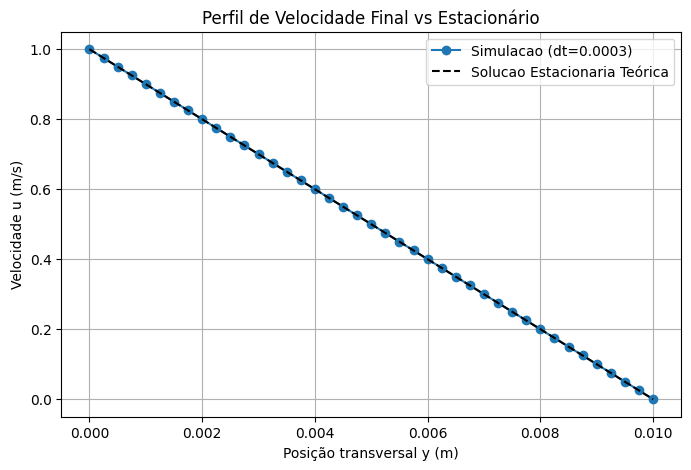

In [9]:
#PARTE 6: Verificação do perfil de velocidade
U = 1.0
y_pontos = res_41_estavel["y"]
u_simulado = res_41_estavel["u"]

# Solução estacionária esperada: u_est(y) = U * (1 - y/H)
u_est = U * (1 - y_pontos / H)

# Cálculo do Erro Máximo E_inf
erro_max = np.max(np.abs(u_simulado - u_est))

print("6. VERIFICAÇÃO DO PERFIL DE VELOCIDADE")
print(f"Diferença máxima em relação ao perfil estacionário (E_inf): {erro_max:.6f} m/s")

plt.figure(figsize=(8, 5))
plt.plot(y_pontos, u_simulado, 'o-', label=f"Simulacao (dt={dt_seguro})")
plt.plot(y_pontos, u_est, 'k--', label="Solucao Estacionaria Teórica")
plt.xlabel("Posição transversal y (m)")
plt.ylabel("Velocidade u (m/s)")
plt.title("Perfil de Velocidade Final vs Estacionário")
plt.legend()
plt.grid(True)
plt.show()



### Resposta 6

Como a diferença máxima em relação ao perfil estacionário resultou em 0.000000 m/s e o gráfico mostra uma sobreposição perfeita das curvas, concluímos que o tempo simulado foi suficiente para o sistema atingir o regime estacionário. Todo o efeito do transiente inicial (aceleração do fluido) já desapareceu e o escoamento se estabilizou por completo.